# 04 — ANN Hazard Score Predictor
**Project:** E-Waste Component Classification | SDG 12.4  
**Technique:** Artificial Neural Network (ANN) on Tabular Data  
**Task:** Predict hazard score (0–100) from e-waste component features

## Cell 1 — Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

ANN_DIR = r"D:\Github Desktop\ewaste_vit_project\models\ann"
os.makedirs(ANN_DIR, exist_ok=True)
print("ANN notebook ready.")

ANN notebook ready.


## Cell 2 — Build Tabular Dataset
> This cell generates a synthetic but realistic e-waste tabular dataset based on published hazard profiles from the Global E-Waste Monitor and Basel Convention guidelines.

In [2]:
# Known hazard profiles per component (from literature)
COMPONENT_PROFILES = {
    "Battery":                  {"hazard_base": 90, "contains_lithium": 1, "contains_lead": 0, "contains_mercury": 0, "recyclable": 0, "material_type": "chemical"},
    "PCB":                      {"hazard_base": 85, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 0, "recyclable": 1, "material_type": "composite"},
    "Mobile":                   {"hazard_base": 80, "contains_lithium": 1, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "composite"},
    "Television":               {"hazard_base": 82, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 1, "recyclable": 0, "material_type": "composite"},
    "light bulbs":              {"hazard_base": 78, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 1, "recyclable": 0, "material_type": "glass"},
    "Microwave":                {"hazard_base": 60, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "metal"},
    "Washing Machine":          {"hazard_base": 45, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "metal"},
    "Printer":                  {"hazard_base": 55, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 0, "recyclable": 1, "material_type": "composite"},
    "Player":                   {"hazard_base": 50, "contains_lithium": 1, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "composite"},
    "Capacitor":                {"hazard_base": 55, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "chemical"},
    "Integrated-micro-circuit": {"hazard_base": 60, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 0, "recyclable": 1, "material_type": "silicon"},
    "microchip":                {"hazard_base": 58, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 0, "recyclable": 1, "material_type": "silicon"},
    "microprocessor":           {"hazard_base": 62, "contains_lithium": 0, "contains_lead": 1, "contains_mercury": 0, "recyclable": 1, "material_type": "silicon"},
    "Keyboard":                 {"hazard_base": 20, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "plastic"},
    "Mouse":                    {"hazard_base": 18, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "plastic"},
    "LED":                      {"hazard_base": 22, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "semiconductor"},
    "Resistor":                 {"hazard_base": 15, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "ceramic"},
    "semiconductor-diode":      {"hazard_base": 25, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "semiconductor"},
    "transistor":               {"hazard_base": 20, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "semiconductor"},
    "heat-sink":                {"hazard_base": 10, "contains_lithium": 0, "contains_lead": 0, "contains_mercury": 0, "recyclable": 1, "material_type": "metal"},
}

rows = []
np.random.seed(42)
N_PER_CLASS = 50  # 50 samples per class = 1000 total rows

for component, profile in COMPONENT_PROFILES.items():
    for _ in range(N_PER_CLASS):
        age_years    = np.random.uniform(0.5, 10)
        weight_kg    = np.random.uniform(0.05, 15)
        condition    = np.random.choice(["working", "damaged", "broken"], p=[0.3, 0.4, 0.3])
        region_risk  = np.random.choice(["low", "medium", "high"], p=[0.3, 0.4, 0.3])

        # Hazard score formula
        base    = profile["hazard_base"]
        noise   = np.random.normal(0, 5)
        age_adj = min(age_years * 1.5, 15)
        cond_adj = {"working": -5, "damaged": 0, "broken": 5}[condition]
        reg_adj  = {"low": -3, "medium": 0, "high": 5}[region_risk]
        score    = np.clip(base + noise + age_adj + cond_adj + reg_adj, 0, 100)

        rows.append({
            "component":          component,
            "age_years":          round(age_years, 2),
            "weight_kg":          round(weight_kg, 2),
            "contains_lithium":   profile["contains_lithium"],
            "contains_lead":      profile["contains_lead"],
            "contains_mercury":   profile["contains_mercury"],
            "recyclable":         profile["recyclable"],
            "material_type":      profile["material_type"],
            "condition":          condition,
            "region_risk":        region_risk,
            "hazard_score":       round(score, 2),
        })

df = pd.DataFrame(rows)
csv_path = os.path.join(ANN_DIR, "ewaste_tabular_dataset.csv")
df.to_csv(csv_path, index=False)

print(f"Dataset created: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Saved to: {csv_path}")
print(df.describe())

Dataset created: 1000 rows x 11 columns
Saved to: D:\Github Desktop\ewaste_vit_project\models\ann\ewaste_tabular_dataset.csv
         age_years    weight_kg  contains_lithium  contains_lead  \
count  1000.000000  1000.000000        1000.00000    1000.000000   
mean      5.174660     7.617020           0.15000       0.300000   
std       2.767612     4.389935           0.35725       0.458487   
min       0.500000     0.070000           0.00000       0.000000   
25%       2.710000     3.797500           0.00000       0.000000   
50%       4.995000     7.700000           0.00000       0.000000   
75%       7.672500    11.485000           0.00000       1.000000   
max       9.990000    14.970000           1.00000       1.000000   

       contains_mercury  recyclable  hazard_score  
count        1000.00000  1000.00000   1000.000000  
mean            0.10000     0.85000     57.461880  
std             0.30015     0.35725     26.620136  
min             0.00000     0.00000      0.060000  
25

## Cell 3 — Preprocessing

In [3]:
# Encode categoricals
le_component = LabelEncoder()
le_material  = LabelEncoder()
le_condition = LabelEncoder()
le_region    = LabelEncoder()

df["component_enc"]  = le_component.fit_transform(df["component"])
df["material_enc"]   = le_material.fit_transform(df["material_type"])
df["condition_enc"]  = le_condition.fit_transform(df["condition"])
df["region_enc"]     = le_region.fit_transform(df["region_risk"])

FEATURES = [
    "component_enc", "age_years", "weight_kg",
    "contains_lithium", "contains_lead", "contains_mercury",
    "recyclable", "material_enc", "condition_enc", "region_enc"
]
TARGET = "hazard_score"

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/val/test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Features: {FEATURES}")

Train: 700 | Val: 150 | Test: 150
Features: ['component_enc', 'age_years', 'weight_kg', 'contains_lithium', 'contains_lead', 'contains_mercury', 'recyclable', 'material_enc', 'condition_enc', 'region_enc']


## Cell 4 — PyTorch Dataset & DataLoader

In [4]:
class EWasteTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):    return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = EWasteTabularDataset(X_train, y_train)
val_ds   = EWasteTabularDataset(X_val,   y_val)
test_ds  = EWasteTabularDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


## Cell 5 — ANN Architecture

In [5]:
class HazardANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # Regression output: hazard score
        )

    def forward(self, x):
        return self.network(x)

model = HazardANN(input_dim=len(FEATURES))
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

HazardANN(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 12,161


## Cell 6 — Training

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

NUM_EPOCHS  = 100
best_val_loss = float("inf")
best_path     = os.path.join(ANN_DIR, "ann_best.pth")
history       = {"train_loss": [], "val_loss": []}

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_ds)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds     = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(X_batch)
    val_loss /= len(val_ds)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

print(f"\nBest Val MSE: {best_val_loss:.4f}")

Epoch 010 | Train MSE: 261.3076 | Val MSE: 190.9070
Epoch 020 | Train MSE: 183.6579 | Val MSE: 147.4799
Epoch 030 | Train MSE: 154.1540 | Val MSE: 130.5988
Epoch 040 | Train MSE: 149.1942 | Val MSE: 112.6260
Epoch 050 | Train MSE: 156.3167 | Val MSE: 95.3915
Epoch 060 | Train MSE: 143.5054 | Val MSE: 101.1201
Epoch 070 | Train MSE: 128.6097 | Val MSE: 89.7056
Epoch 080 | Train MSE: 130.7820 | Val MSE: 83.9209
Epoch 090 | Train MSE: 121.4739 | Val MSE: 75.8186
Epoch 100 | Train MSE: 128.4432 | Val MSE: 73.1532

Best Val MSE: 71.4558


## Cell 7 — Loss Curve

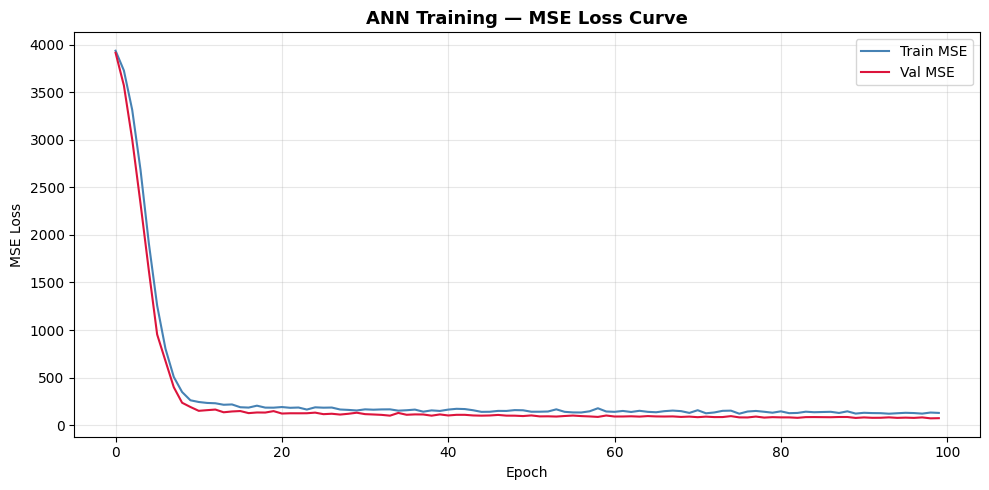

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train MSE", color="steelblue")
plt.plot(history["val_loss"],   label="Val MSE",   color="crimson")
plt.title("ANN Training — MSE Loss Curve", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANN_DIR, "ann_loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 8 — Test Evaluation

Test MAE : 7.6415  (avg error in hazard score points)
Test R²  : 0.8771  (1.0 = perfect)


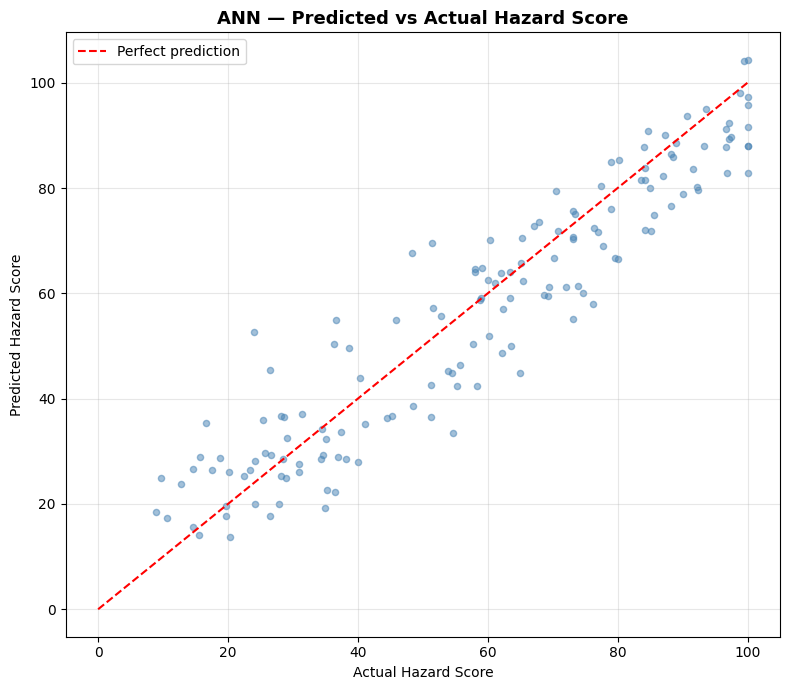

In [8]:
model.load_state_dict(torch.load(best_path, map_location="cpu"))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        all_preds.extend(preds.squeeze().numpy())
        all_targets.extend(y_batch.squeeze().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mae = mean_absolute_error(all_targets, all_preds)
r2  = r2_score(all_targets, all_preds)

print(f"Test MAE : {mae:.4f}  (avg error in hazard score points)")
print(f"Test R²  : {r2:.4f}  (1.0 = perfect)")

# Scatter plot
plt.figure(figsize=(8, 7))
plt.scatter(all_targets, all_preds, alpha=0.5, s=20, color="steelblue")
plt.plot([0, 100], [0, 100], "r--", label="Perfect prediction")
plt.title("ANN — Predicted vs Actual Hazard Score", fontsize=13, fontweight="bold")
plt.xlabel("Actual Hazard Score")
plt.ylabel("Predicted Hazard Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANN_DIR, "predicted_vs_actual.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — Hazard Class Accuracy

Hazard Class Classification Report:
              precision    recall  f1-score   support

        HIGH       0.92      0.84      0.88        58
         LOW       0.86      0.90      0.88        48
      MEDIUM       0.70      0.75      0.73        44

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.84      0.83      0.83       150

Hazard Class Accuracy: 0.8333


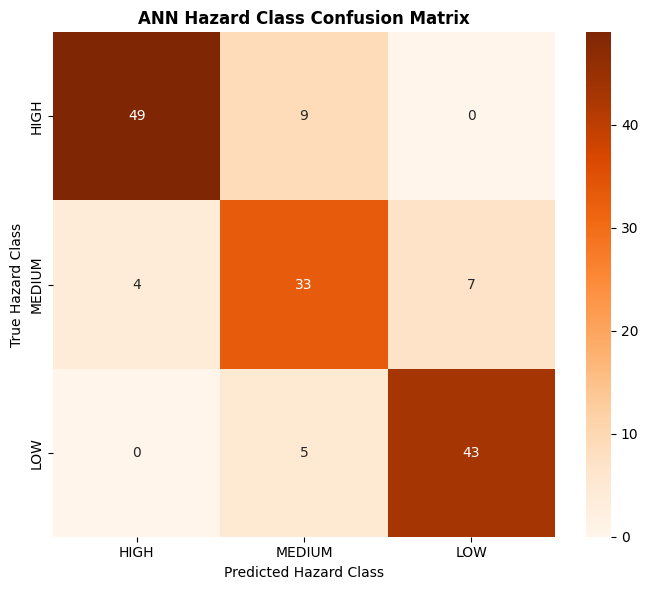

In [9]:
def score_to_class(scores):
    return ["HIGH" if s >= 70 else "MEDIUM" if s >= 40 else "LOW"
            for s in scores]

pred_classes   = score_to_class(all_preds)
target_classes = score_to_class(all_targets)

from sklearn.metrics import classification_report, accuracy_score
print("Hazard Class Classification Report:")
print(classification_report(target_classes, pred_classes,
                             target_names=["HIGH", "LOW", "MEDIUM"]))

acc = accuracy_score(target_classes, pred_classes)
print(f"Hazard Class Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(target_classes, pred_classes,
                      labels=["HIGH", "MEDIUM", "LOW"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["HIGH", "MEDIUM", "LOW"],
            yticklabels=["HIGH", "MEDIUM", "LOW"])
plt.title("ANN Hazard Class Confusion Matrix", fontsize=12, fontweight="bold")
plt.ylabel("True Hazard Class")
plt.xlabel("Predicted Hazard Class")
plt.tight_layout()
plt.savefig(os.path.join(ANN_DIR, "hazard_class_confusion.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 10 — Feature Importance

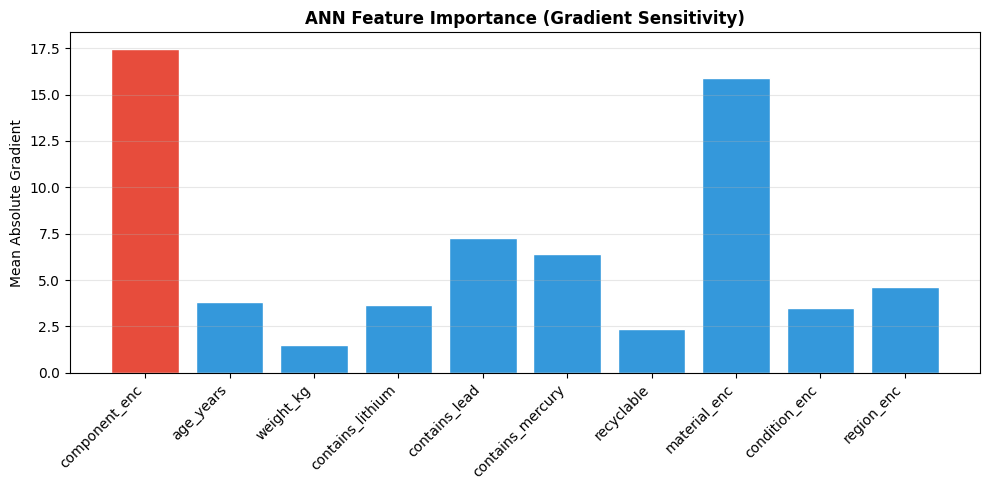

In [10]:
# Compute feature importance via gradient sensitivity
model.eval()
X_tensor = torch.tensor(X_test, dtype=torch.float32, requires_grad=True)
preds    = model(X_tensor)
preds.sum().backward()
importance = X_tensor.grad.abs().mean(dim=0).detach().numpy()

plt.figure(figsize=(10, 5))
colors = ["#e74c3c" if imp == importance.max() else "#3498db" for imp in importance]
plt.bar(FEATURES, importance, color=colors, edgecolor="white")
plt.title("ANN Feature Importance (Gradient Sensitivity)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Absolute Gradient")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANN_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

## Cell 11 — Save Results

In [11]:
results = {
    "model"               : "ANN (Hazard Score Predictor)",
    "test_mae"            : round(float(mae), 4),
    "test_r2"             : round(float(r2), 4),
    "hazard_class_accuracy": round(float(acc), 4),
    "features"            : FEATURES,
    "num_epochs"          : NUM_EPOCHS,
    "best_val_mse"        : round(float(best_val_loss), 4),
}

with open(os.path.join(ANN_DIR, "ann_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("ANN results saved.")
print(json.dumps(results, indent=2))

ANN results saved.
{
  "model": "ANN (Hazard Score Predictor)",
  "test_mae": 7.6415,
  "test_r2": 0.8771,
  "hazard_class_accuracy": 0.8333,
  "features": [
    "component_enc",
    "age_years",
    "weight_kg",
    "contains_lithium",
    "contains_lead",
    "contains_mercury",
    "recyclable",
    "material_enc",
    "condition_enc",
    "region_enc"
  ],
  "num_epochs": 100,
  "best_val_mse": 71.4558
}
